Mínimos cuadrados en los puntos $(Px[i],Py[i])$

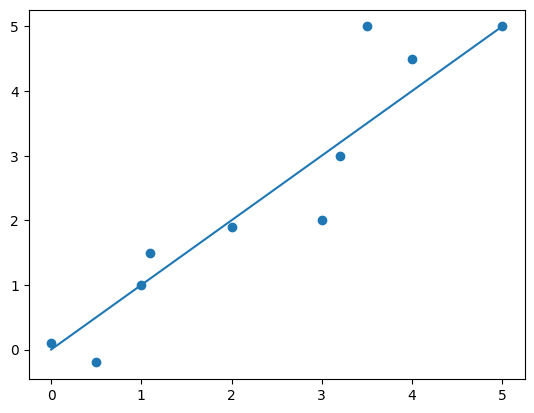

In [1]:
import matplotlib.pyplot as plt
import numpy as np

Px=[0,.5,1,1.1,2,3,3.2,3.5,4,5]
Py=[.1,-.2,1,1.5,1.9,2,3,5,4.5,5]

Sx=0
Sy=0
for i in Px:
    Sx=Sx+i
    Sy=Sy+i
Sx=Sx/len(Px)
Sy=Sy/len(Py)

m1,m2=0,0
for i in range(len(Px)):
    m1=(Px[i]-Sx)*(Py[i]-Sy)
    m2=(Px[i]-Sx)**2

m=m1/m2
b=Sy-m*Sx

X=np.linspace(0,5,10)
Y=m*X+b

plt.scatter(Px,Py)
plt.plot(X,Y)
plt.show()

Aproximación con polinomios de Lagrange para la función \
\
$f(x)=\frac{1}{1+25x^2}$, $x\in [-1,1]$

P(x)=9.79494263475544e-14*x**9 + 21.6247747536391*x**8 - 1.13492548692307e-13*x**7 - 44.9154580808919*x**6 + 7.68378416449167e-14*x**5 + 30.7285300420963*x**4 - 2.87974939033875e-14*x**3 - 8.26092332834773*x**2 + 1.48502493938982e-15*x + 0.861538151965819


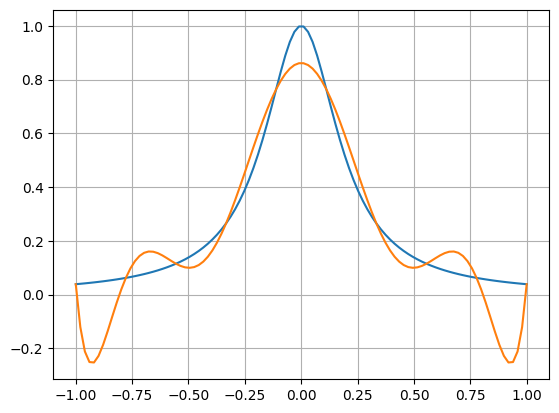

In [18]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

def F(X):
    return 1/(1+25*X**2)

n=10
X=np.linspace(-1,1,n)
Y=F(X)

x=sp.symbols('x')
if len(X)==len(Y):
    f=0
    for i in range(len(X)):
        f_i=1
        for j in range(len(X)):
            if j!=i:
                fac=(x-X[j])/(X[i]-X[j])
                f_i=f_i*(fac)
        f_i=sp.expand(f_i)
        f=f+Y[i]*f_i

    print(f"P(x)={f}")
    P=sp.lambdify(x,f,'numpy')
else:
    print("Error")

V=np.linspace(-1,1,100)

plt.plot(V,F(V))
plt.plot(V,P(V))

plt.grid()
plt.show()

Aproximación con el polinómio de diferencias divividas de Newton para la función \
\
$f(x)=|x|+0.2sin(10x)$, $x \in [-1,1]$

P_n= 79.6269332563558*x**9 - 4.63379778180803*x**8 - 170.702299841441*x**7 + 9.93120117187495*x**6 + 118.930571186203*x**5 - 7.40588378906247*x**4 - 29.928839085428*x**3 + 3.03371233258928*x**2 + 1.96483026213315*x + 0.0747680664062501


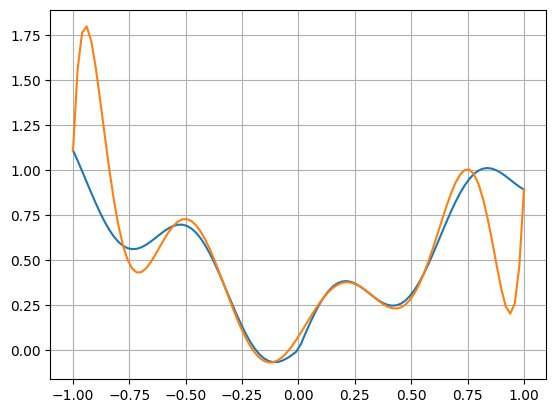

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

def f(x):
    return abs(x) + 0.2*np.sin(10*x)

n=10
X=np.linspace(-1,1,n)

def dd(X,i,ik):
    if i==ik:
        d_d=f(X[i])
    else:
        d_d=(dd(X,i+1,ik)-dd(X,i,ik-1))/(X[ik]-X[i])
    return d_d

x=sp.symbols('x')
P_n=0
P=1
for l in range(len(X)):
    if l!=0:
        P=P*(x-X[l-1])
    P_n=P_n+dd(X,0,l)*P
    P_n=sp.expand(P_n)

print("P_n=",P_n)
Pf=sp.lambdify(x,P_n,'numpy')
V=np.linspace(-1,1,100)

plt.plot(V,f(V))
plt.plot(V,Pf(V))

plt.grid()
plt.show()